In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import KFold

In [2]:
df = pd.read_parquet("../Data/Parquet/enhanced_summed_47photic.parquet", engine='pyarrow')

In [3]:
print(df.columns)

Index(['ORD_OCC', 'CAST_ID', 'DATE_TIME_UTC', 'DATE_TIME_PST', 'LAT_DEC',
       'LON_DEC', 'STA_ID', 'LINE', 'STA', 'DEPTH', 'PRESSURE',
       'ESTCHL_CRUISECORR', 'ESTCHL_STACORR', 'BAT', 'XMISS', 'SPAR', 'PAR',
       'CHL_A', 'PHAEO', 'CAST_COUNT', 'PHOTIC_ZONE', 'XMISS_SUMMED',
       'CHL_A_SUMMED', 'Cruise_ID', 'Cruz_Sta', 'Cast_ID', 'Sta_ID',
       'Distance', 'Date', 'Time', 'Lat_Dec', 'Lon_Dec', 'Ac_Line', 'Bottom_D',
       'Secchi', 'IntChl', 'IntC14', 'TimeZone', 'Visibility', 'K_PAR',
       'K_PAR_SLOPE'],
      dtype='object')


In [30]:
from sklearn.linear_model import LassoCV, Lasso
from sklearn.model_selection import train_test_split, KFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score

# ── Feature & target selection ──────────────────────────────────────────────
FEATURES = ['Lat_Dec', 'STA', 'DEPTH', 'CHL_A_SUMMED',
            'K_PAR', 'K_PAR_SLOPE', 'PAR', 'ESTCHL_STACORR']
TARGET   = 'Secchi'

df_model = df[FEATURES + [TARGET]].dropna()
print(f"Rows after dropping NaNs: {len(df_model)}")

X = df_model[FEATURES].values
y = df_model[TARGET].values


Rows after dropping NaNs: 1971


In [31]:
# ── 80/20 Train / Test split ────────────────────────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)
print(f"Train size: {len(X_train)}  |  Test size: {len(X_test)}")

# ── Standardise features (fit on train only) ─────────────────────────────────
scaler  = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test  = scaler.transform(X_test)


Train size: 1576  |  Test size: 395


In [32]:
# ── LASSO with 5-fold CV to select optimal alpha ─────────────────────────────
kf = KFold(n_splits=5, shuffle=True, random_state=42)

alphas = np.logspace(-4, 2, 200)          # search grid: 0.0001 → 100

lasso_cv = LassoCV(
    alphas=alphas,
    cv=kf,
    max_iter=10_000,
    random_state=42
)
lasso_cv.fit(X_train, y_train)

best_alpha = lasso_cv.alpha_
print(f"Best alpha (λ): {best_alpha:.6f}")
print(f"CV MSE path shape (alphas × folds): {lasso_cv.mse_path_.shape}")


Best alpha (λ): 0.000100
CV MSE path shape (alphas × folds): (200, 5)


In [33]:
# ── Evaluate on held-out test set ────────────────────────────────────────────
y_pred = lasso_cv.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2   = r2_score(y_test, y_pred)

print("── Test-set performance ──────────────────────────────")
print(f"  RMSE : {rmse:.4f}")
print(f"  R²   : {r2:.4f}")

# ── Coefficients table ────────────────────────────────────────────────────────
coef_df = (
    pd.DataFrame({'Feature': FEATURES, 'Coefficient': lasso_cv.coef_})
    .reindex(pd.Series(np.abs(lasso_cv.coef_)).sort_values(ascending=False).index)
    .reset_index(drop=True)
)
print("\n── Feature coefficients (sorted by |coef|) ───────────")
print(coef_df.to_string(index=False))


── Test-set performance ──────────────────────────────
  RMSE : 5.5429
  R²   : 0.6040

── Feature coefficients (sorted by |coef|) ───────────
       Feature  Coefficient
         DEPTH     4.357833
         K_PAR     3.965210
   K_PAR_SLOPE    -3.635072
       Lat_Dec    -1.700673
  CHL_A_SUMMED    -1.530340
           STA     1.252264
           PAR     0.471171
ESTCHL_STACORR    -0.055409


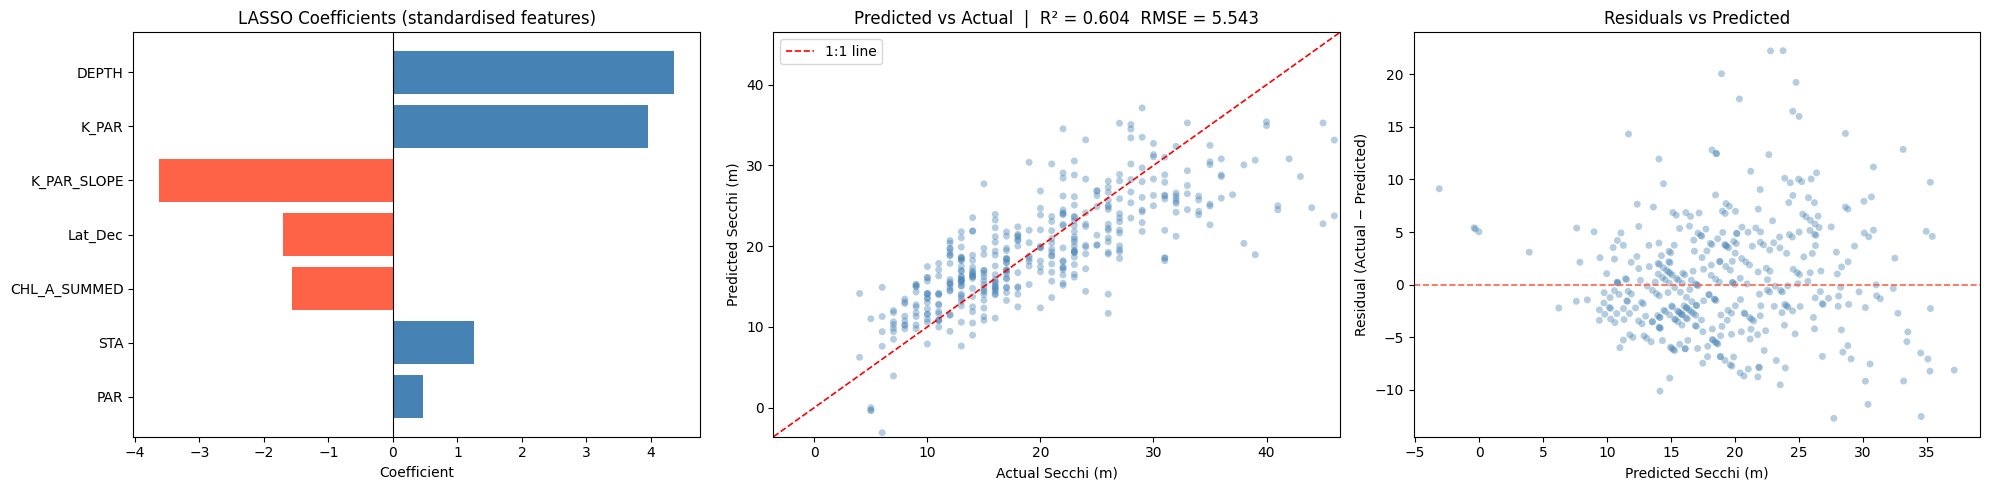

In [18]:
# ── Visualisations ────────────────────────────────────────────────────────────
residuals = y_test - y_pred

fig, axes = plt.subplots(1, 3, figsize=(20, 5))

# 1. Coefficient bar chart
ax = axes[0]
colors = ['tomato' if c < 0 else 'steelblue' for c in coef_df['Coefficient']]
ax.barh(coef_df['Feature'], coef_df['Coefficient'], color=colors)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Coefficient')
ax.set_title('LASSO Coefficients (standardised features)')
ax.invert_yaxis()

# 2. Predicted vs Actual
ax = axes[1]
lims = [min(y_test.min(), y_pred.min()) - 0.5,
        max(y_test.max(), y_pred.max()) + 0.5]
ax.scatter(y_test, y_pred, alpha=0.4, edgecolors='none', color='steelblue', s=25)
ax.plot(lims, lims, 'r--', linewidth=1.2, label='1:1 line')
ax.set_xlim(lims); ax.set_ylim(lims)
ax.set_xlabel('Actual Secchi (m)')
ax.set_ylabel('Predicted Secchi (m)')
ax.set_title(f'Predicted vs Actual  |  R² = {r2:.3f}  RMSE = {rmse:.3f}')
ax.legend()

# 3. Residuals vs Predicted
ax = axes[2]
ax.scatter(y_pred, residuals, alpha=0.4, edgecolors='none', color='steelblue', s=25)
ax.axhline(0, color='tomato', linestyle='--', linewidth=1.2)
ax.set_xlabel('Predicted Secchi (m)')
ax.set_ylabel('Residual (Actual − Predicted)')
ax.set_title('Residuals vs Predicted')

plt.tight_layout()
plt.show()


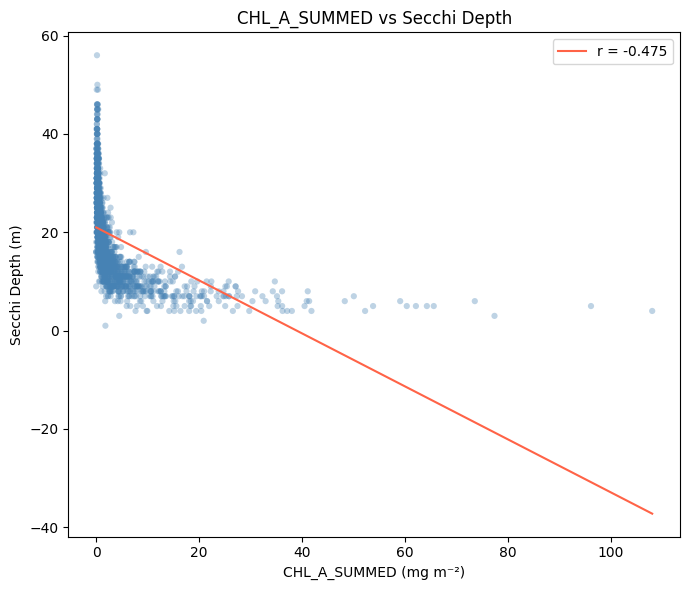

In [34]:
# ── CHL_A_SUMMED vs Secchi correlation scatterplot ───────────────────────────
r = df_model['CHL_A_SUMMED'].corr(df_model['Secchi'])

fig, ax = plt.subplots(figsize=(7, 6))
ax.scatter(df_model['CHL_A_SUMMED'], df_model['Secchi'],
           alpha=0.35, edgecolors='none', color='steelblue', s=20)

# linear trend line
m, b = np.polyfit(df_model['CHL_A_SUMMED'], df_model['Secchi'], 1)
x_line = np.linspace(df_model['CHL_A_SUMMED'].min(), df_model['CHL_A_SUMMED'].max(), 200)
ax.plot(x_line, m * x_line + b, color='tomato', linewidth=1.5, label=f'r = {r:.3f}')

ax.set_xlabel('CHL_A_SUMMED (mg m⁻²)')
ax.set_ylabel('Secchi Depth (m)')
ax.set_title('CHL_A_SUMMED vs Secchi Depth')
ax.legend()
plt.tight_layout()
plt.show()


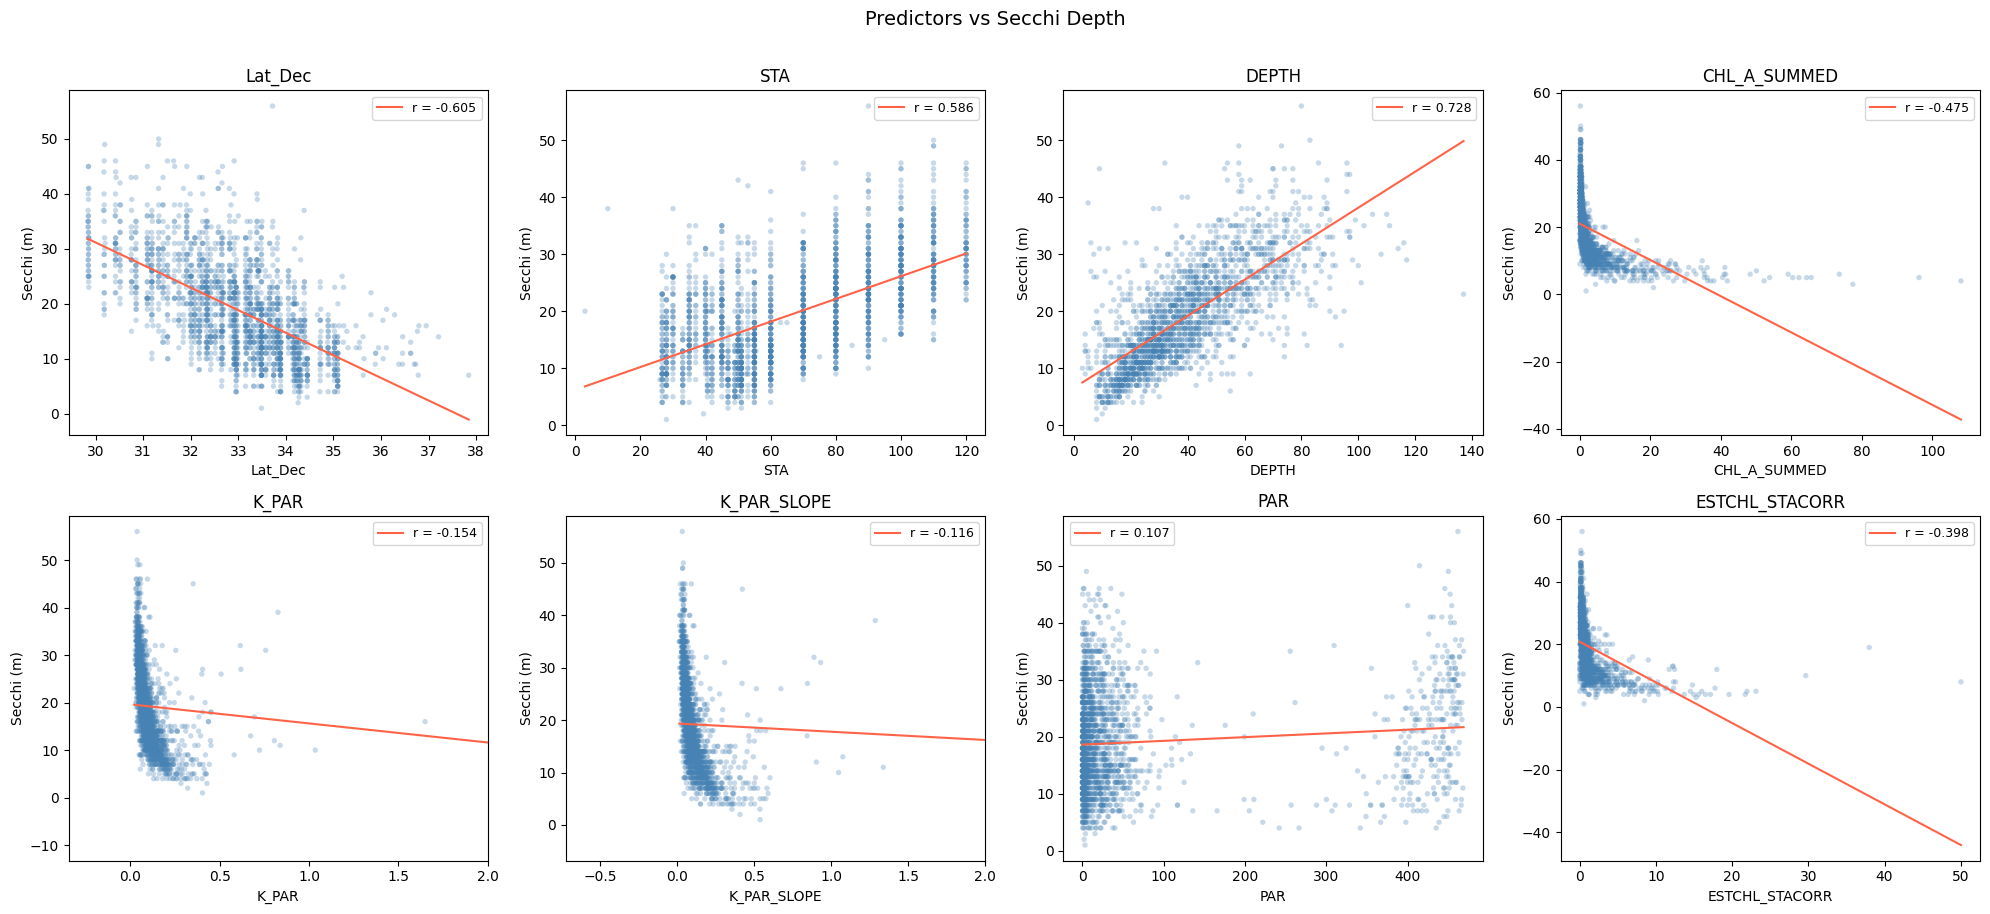

In [35]:
# ── All predictors vs Secchi ──────────────────────────────────────────────────
n_cols = 4
n_rows = int(np.ceil(len(FEATURES) / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 9))
axes = axes.flatten()

X_RANGE_OVERRIDES = {'K_PAR': 2, 'K_PAR_SLOPE': 2}

for i, feature in enumerate(FEATURES):
    ax = axes[i]
    r = df_model[feature].corr(df_model['Secchi'])

    ax.scatter(df_model[feature], df_model['Secchi'],
               alpha=0.3, edgecolors='none', color='steelblue', s=15)

    m, b = np.polyfit(df_model[feature], df_model['Secchi'], 1)
    x_line = np.linspace(df_model[feature].min(), df_model[feature].max(), 200)
    ax.plot(x_line, m * x_line + b, color='tomato', linewidth=1.5, label=f'r = {r:.3f}')

    ax.set_xlabel(feature)
    ax.set_ylabel('Secchi (m)')
    ax.set_title(feature)
    ax.legend(fontsize=9)

    if feature in X_RANGE_OVERRIDES:
        ax.set_xlim(right=X_RANGE_OVERRIDES[feature])

# hide any unused axes
for j in range(len(FEATURES), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Predictors vs Secchi Depth', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()


In [36]:
# ── Refit: log-transform CHL_A_SUMMED and ESTCHL_STACORR ─────────────────────
df_log = df_model.copy()
df_log['LOG_CHL_A_SUMMED']   = np.log1p(df_log['CHL_A_SUMMED'])
df_log['LOG_ESTCHL_STACORR'] = np.log1p(df_log['ESTCHL_STACORR'])

FEATURES_LOG = ['Lat_Dec', 'STA', 'DEPTH', 'LOG_CHL_A_SUMMED',
                'K_PAR', 'K_PAR_SLOPE', 'PAR', 'LOG_ESTCHL_STACORR']

X_log = df_log[FEATURES_LOG].values
y_log = df_log[TARGET].values

# 80/20 split (same random state for fair comparison)
X_log_train, X_log_test, y_log_train, y_log_test = train_test_split(
    X_log, y_log, test_size=0.20, random_state=42
)

scaler_log   = StandardScaler()
X_log_train  = scaler_log.fit_transform(X_log_train)
X_log_test   = scaler_log.transform(X_log_test)

# 5-fold LassoCV
lasso_log = LassoCV(alphas=alphas, cv=kf, max_iter=10_000, random_state=42)
lasso_log.fit(X_log_train, y_log_train)

y_log_pred  = lasso_log.predict(X_log_test)
rmse_log    = np.sqrt(mean_squared_error(y_log_test, y_log_pred))
r2_log      = r2_score(y_log_test, y_log_pred)

print(f"Best alpha (λ): {lasso_log.alpha_:.6f}")
print(f"\n── Test-set performance (log-transformed features) ──────────")
print(f"  RMSE : {rmse_log:.4f}  (original: {rmse:.4f})")
print(f"  R²   : {r2_log:.4f}  (original: {r2:.4f})")

coef_log_df = (
    pd.DataFrame({'Feature': FEATURES_LOG, 'Coefficient': lasso_log.coef_})
    .reindex(pd.Series(np.abs(lasso_log.coef_)).sort_values(ascending=False).index)
    .reset_index(drop=True)
)
print("\n── Feature coefficients (sorted by |coef|) ───────────")
print(coef_log_df.to_string(index=False))


Best alpha (λ): 0.004248

── Test-set performance (log-transformed features) ──────────
  RMSE : 5.1150  (original: 5.5429)
  R²   : 0.6628  (original: 0.6040)

── Feature coefficients (sorted by |coef|) ───────────
           Feature  Coefficient
  LOG_CHL_A_SUMMED    -3.935330
             K_PAR     3.719753
       K_PAR_SLOPE    -3.351439
             DEPTH     3.107925
           Lat_Dec    -0.999175
               STA     0.961697
               PAR     0.526258
LOG_ESTCHL_STACORR     0.354118


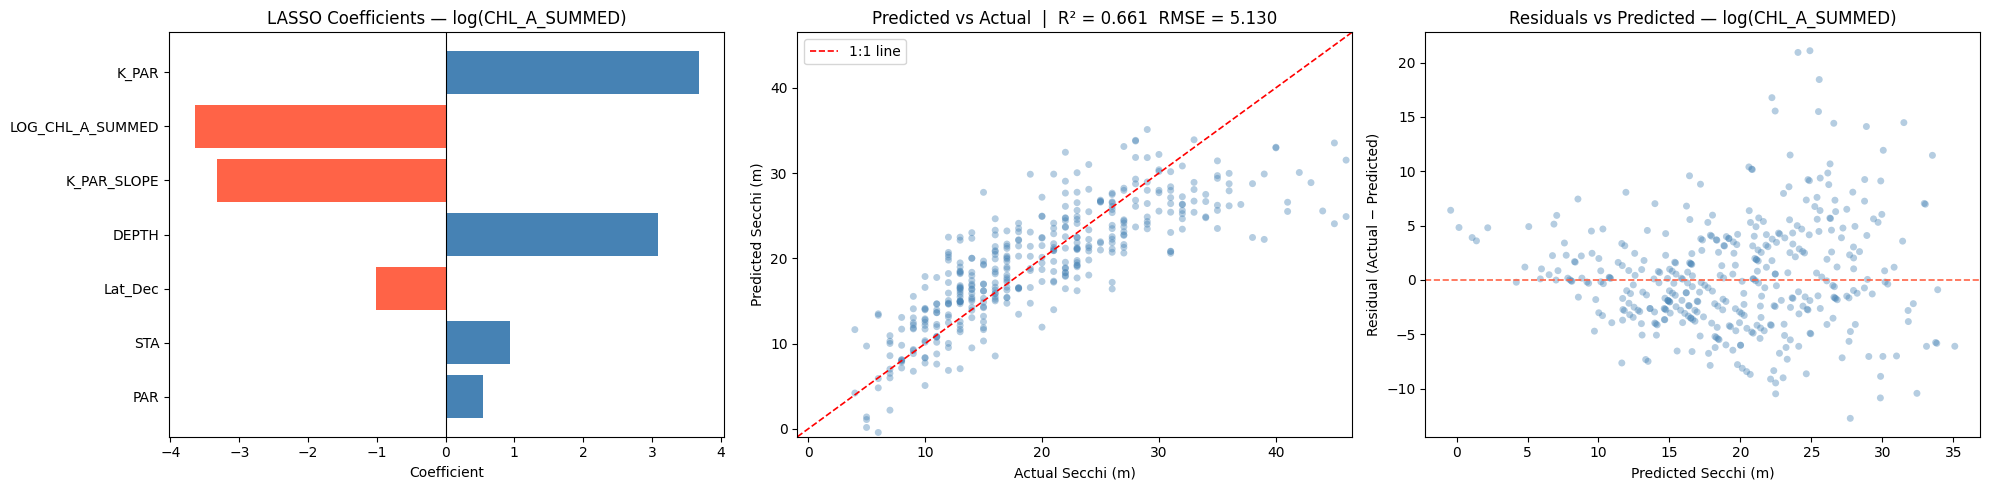

In [23]:
# ── Diagnostics: log-transformed refit ───────────────────────────────────────
residuals_log = y_log_test - y_log_pred

fig, axes = plt.subplots(1, 3, figsize=(20, 5))

# 1. Coefficient bar chart
ax = axes[0]
colors = ['tomato' if c < 0 else 'steelblue' for c in coef_log_df['Coefficient']]
ax.barh(coef_log_df['Feature'], coef_log_df['Coefficient'], color=colors)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Coefficient')
ax.set_title('LASSO Coefficients — log(CHL_A_SUMMED)')
ax.invert_yaxis()

# 2. Predicted vs Actual
ax = axes[1]
lims = [min(y_log_test.min(), y_log_pred.min()) - 0.5,
        max(y_log_test.max(), y_log_pred.max()) + 0.5]
ax.scatter(y_log_test, y_log_pred, alpha=0.4, edgecolors='none', color='steelblue', s=25)
ax.plot(lims, lims, 'r--', linewidth=1.2, label='1:1 line')
ax.set_xlim(lims); ax.set_ylim(lims)
ax.set_xlabel('Actual Secchi (m)')
ax.set_ylabel('Predicted Secchi (m)')
ax.set_title(f'Predicted vs Actual  |  R² = {r2_log:.3f}  RMSE = {rmse_log:.3f}')
ax.legend()

# 3. Residuals vs Predicted
ax = axes[2]
ax.scatter(y_log_pred, residuals_log, alpha=0.4, edgecolors='none', color='steelblue', s=25)
ax.axhline(0, color='tomato', linestyle='--', linewidth=1.2)
ax.set_xlabel('Predicted Secchi (m)')
ax.set_ylabel('Residual (Actual − Predicted)')
ax.set_title('Residuals vs Predicted — log(CHL_A_SUMMED)')

plt.tight_layout()
plt.show()
